# MM26 Machine Learning Model Walkthrough

## The "Cinderella System"

This notebook walks through, step by step, how the machine learning pipeline powering our March Madness predictions works. The thesis is the **Cinderella System** — a model that identifies teams *outperforming expectations* using a "heat" variable, then blends that with traditional ELO-based predictions and Monte Carlo bracket simulations.

### How It Works

1. **ELO Engine** — Establish baseline expectations using margin-of-victory ELO with season carry-over and home court advantage
2. **Heat Variable** — Compare actual performance to ELO expectations over 1, 3, and 5-game windows, plus heat trend and absolute heat
3. **Feature Engineering** — Build 24 pairwise difference features including box score stats, SOS, and seed interactions
4. **XGBoost Model** — Train a gradient-boosted classifier on historical tournament outcomes (2003–2024)
5. **Isotonic Calibration** — Calibrate raw probabilities using out-of-fold predictions from time-series CV
6. **Dynamic Clipping** — Seed-matchup-aware probability bounds (wider for 1v16, narrower for 8v9)
7. **Monte Carlo Simulation** — Run 100,000 bracket simulations to produce consensus predictions
8. **Blend** — Combine XGBoost model predictions (60%) with simulation predictions (40%)

### Where the Submission Lives

The final Kaggle submission file is at: **`artifacts/latest/submission.csv`**

Format: `ID,Pred` where `ID = Season_TeamLow_TeamHigh` and `Pred = P(TeamLow wins)`.

---

In [2]:
from __future__ import annotations
import json, sys
from pathlib import Path
import numpy as np
import polars as pl

# Add project root to path so we can import pipeline helpers
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

BASE = ROOT / "artifacts" / "latest"

# Load run manifest and model diagnostics
manifest = json.loads((BASE / "run_manifest.json").read_text(encoding="utf-8"))
perf = json.loads((BASE / "reports" / "model_performance_summary.json").read_text(encoding="utf-8"))

# Load gold-layer artifacts
elo_ratings = pl.read_parquet(BASE / "gold" / "elo_ratings.parquet")
heat_scores = pl.read_parquet(BASE / "gold" / "heat_scores.parquet")
team_features = pl.read_parquet(BASE / "gold" / "team_season_features.parquet")
pairwise_features = pl.read_parquet(BASE / "gold" / "pairwise_features.parquet")
submission = pl.read_csv(BASE / "submission.csv")

# Load team names for display
teams = pl.read_csv(ROOT / "data" / "MTeams.csv").select("TeamID", "TeamName")
seeds_all = pl.read_csv(ROOT / "data" / "MNCAATourneySeeds.csv")
seeds_2026 = seeds_all.filter(pl.col("Season") == 2026)
slots_2026 = pl.read_csv(ROOT / "data" / "MNCAATourneySlots.csv").filter(pl.col("Season") == 2026)

# Optional: matplotlib for charts
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    print("matplotlib not installed — charts will be skipped")

print(f"Run ID        : {manifest['run_id']}")
print(f"Target season : {manifest['target_season']}")
print(f"Model type    : {perf['model_stats']['M']['model_type']}")
print(f"Holdout Brier : {perf['model_stats']['M']['holdout_brier']:.4f}")
print(f"Simulation    : {perf['simulation']['simulated']} ({perf['simulation'].get('M_matchups_simulated', 0)} M matchups)")
print(f"\nGold artifacts loaded:")
print(f"  elo_ratings      : {elo_ratings.shape}")
print(f"  heat_scores      : {heat_scores.shape}")
print(f"  team_features    : {team_features.shape}")
print(f"  pairwise_features: {pairwise_features.shape}")
print(f"  submission       : {submission.shape}")

Run ID        : 20260318T125500Z_7ebe857f
Target season : 2026
Model type    : xgboost
Holdout Brier : 0.1326
Simulation    : True (202 M matchups)

Gold artifacts loaded:
  elo_ratings      : (423432, 11)
  heat_scores      : (423432, 8)
  team_features    : (14311, 38)
  pairwise_features: (132133, 104)
  submission       : (132133, 2)


---

## Step 1 — The ELO Engine

ELO is a rating system originally designed for chess. Every team starts at **1500** in their first season, with 33% carry-over of prior season deviation in subsequent seasons. After each game, ratings shift based on the result vs. expectations:

- **K-factor = 20** (base), scaled by **margin-of-victory**: $K_{\text{eff}} = K \times \frac{\log(|\text{margin}|+1) \times 2.2}{\Delta_{\text{ELO}} \times 0.001 + 2.2}$
- **Home court advantage**: +100 ELO for the home team
- **Expected win probability**: $P(\text{low wins}) = \frac{1}{1 + 10^{-(\text{ELO}_\text{low} - \text{ELO}_\text{high}) / 400}}$
- **Expected margin**: $25 \times (2 \times P(\text{low wins}) - 1)$
- **Season carry-over**: $\text{ELO}_{\text{new season}} = 1500 + 0.33 \times (\text{ELO}_{\text{end prev}} - 1500)$

A team that beats a much higher-rated opponent *by a large margin* will gain more ELO than one that barely wins. By season's end, the top ELO teams are the ones that have *consistently performed well against quality opponents*.

Let's look at how ELO evolved for a few 2026 tournament teams:

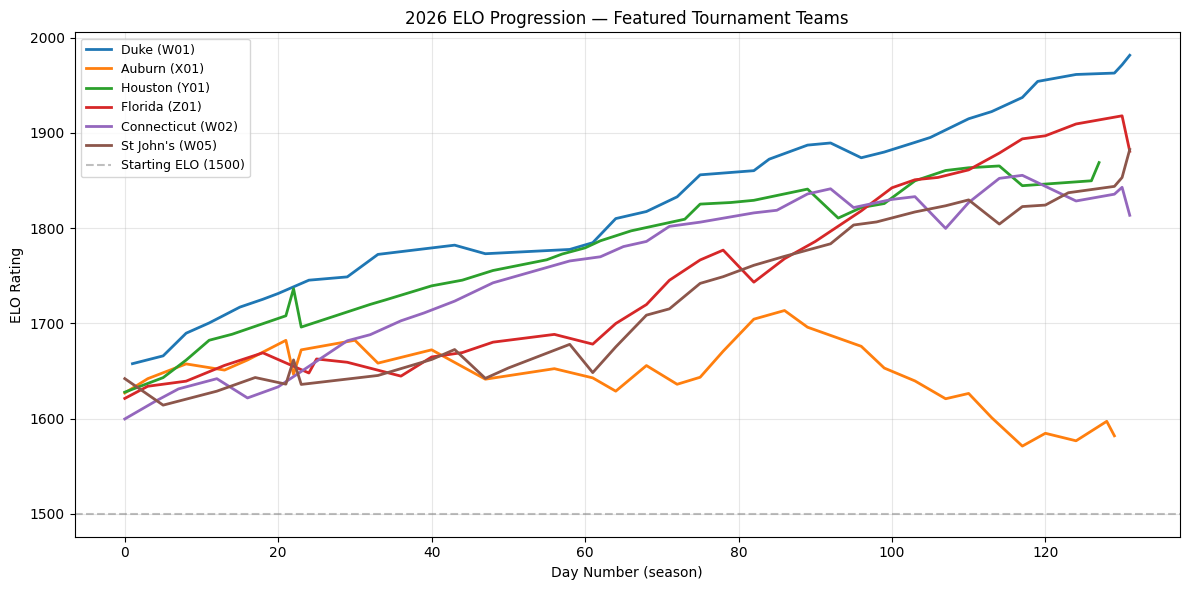

In [3]:
# ELO progression for featured 2026 tournament teams
FEATURED_TEAMS = {
    1181: "Duke (W01)",
    1120: "Auburn (X01)",
    1211: "Houston (Y01)",
    1196: "Florida (Z01)",
    1163: "Connecticut (W02)",
    1385: "St John's (W05)",
}

elo_2026 = elo_ratings.filter(
    (pl.col("sex") == "M") & (pl.col("season") == 2026)
)

if HAS_PLT:
    fig, ax = plt.subplots(figsize=(12, 6))
    for tid, label in FEATURED_TEAMS.items():
        team_elo = elo_2026.filter(pl.col("team_id") == tid).sort("day_num")
        if team_elo.height > 0:
            ax.plot(
                team_elo["day_num"].to_numpy(),
                team_elo["elo_after"].to_numpy(),
                label=label, linewidth=2,
            )
    ax.axhline(y=1500, color="gray", linestyle="--", alpha=0.5, label="Starting ELO (1500)")
    ax.set_xlabel("Day Number (season)")
    ax.set_ylabel("ELO Rating")
    ax.set_title("2026 ELO Progression — Featured Tournament Teams")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Text fallback
    for tid, label in FEATURED_TEAMS.items():
        team_elo = elo_2026.filter(pl.col("team_id") == tid).sort("day_num")
        if team_elo.height > 0:
            final_elo = team_elo["elo_after"][-1]
            print(f"  {label:25s} → Final ELO: {final_elo:.1f}")

In [4]:
# Top 20 teams by season-end ELO for 2026 Men's tournament
m_2026_features = team_features.filter(
    (pl.col("sex") == "M") & (pl.col("season") == 2026)
)

# Join with seeds and team names
tourney_teams = (
    m_2026_features
    .join(seeds_2026.select(
        pl.col("TeamID").cast(pl.Int64).alias("team_id"),
        pl.col("Seed"),
    ), on="team_id", how="inner")
    .join(teams.rename({"TeamID": "team_id"}), on="team_id", how="left")
    .with_columns(
        pl.col("Seed").str.extract(r"(\d+)", 1).cast(pl.Int64).alias("seed_num"),
    )
    .sort("season_end_elo", descending=True)
)

print("Top 20 Teams by ELO — 2026 Men's Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>8} {'Win Rate':>10} {'Record':>10}")
print("─" * 60)
for row in tourney_teams.head(20).iter_rows(named=True):
    record = f"{row['wins']}-{row['losses']}"
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>8.1f} {row['win_rate']:>9.1%} {record:>10}")

Top 20 Teams by ELO — 2026 Men's Tournament

Seed   Team                        ELO   Win Rate     Record
────────────────────────────────────────────────────────────
W01    Duke                     1981.6     94.1%       32-2
Z01    Arizona                  1948.5     94.1%       32-2
Y01    Michigan                 1943.6     91.2%       31-3
W05    St John's                1882.6     82.4%       28-6
X01    Florida                  1880.8     78.8%       26-7
Z03    Gonzaga                  1868.9     90.9%       30-3
X02    Houston                  1844.4     82.4%       28-6
Y03    Virginia                 1837.5     85.3%       29-5
Z02    Purdue                   1836.1     77.1%       27-8
X07    St Mary's CA             1816.3     83.9%       26-5
Z04    Arkansas                 1814.8     76.5%       26-8
W02    Connecticut              1813.5     85.3%       29-5
X11    VCU                      1808.3     79.4%       27-7
Y12    Akron                    1803.5     84.4%     

---

## Step 2 — The Heat Variable (Cinderella Detection)

The **heat variable** is the core innovation. It measures how much a team is *outperforming their ELO-based expectations*:

$$\text{heat\_delta} = \text{actual\_margin} - \text{expected\_margin}$$

We compute rolling averages over three lookback windows:
- **heat_1g** — Last 1 game (most recent momentum)
- **heat_3g** — Average of last 3 games (short-term trend)
- **heat_5g** — Average of last 5 games (sustained over-performance)

A team with **positive heat** heading into the tournament is winning by *more* than their ELO predicts — they're "hot." A team with **negative heat** is underperforming expectations — they're "cold."

The hypothesis: **hot teams are more likely to pull upsets**, and this signal improves our predictions beyond what traditional stats capture.

In [5]:
# Show the hottest and coldest teams entering the 2026 Men's tournament
heat_display = (
    tourney_teams
    .select("Seed", "TeamName", "season_end_elo", "pre_tourney_heat_1g", "pre_tourney_heat_3g", "pre_tourney_heat_5g")
)

print("🔥 HOTTEST Teams (by 5-game heat) entering 2026 Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Heat 1g':>9} {'Heat 3g':>9} {'Heat 5g':>9}")
print("─" * 65)
hot = heat_display.sort("pre_tourney_heat_5g", descending=True).head(10)
for row in hot.iter_rows(named=True):
    h1 = row["pre_tourney_heat_1g"] or 0
    h3 = row["pre_tourney_heat_3g"] or 0
    h5 = row["pre_tourney_heat_5g"] or 0
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>7.1f} {h1:>+9.2f} {h3:>+9.2f} {h5:>+9.2f}")

print("\n\n❄️  COLDEST Teams (by 5-game heat) entering 2026 Tournament\n")
print(f"{'Seed':<6} {'Team':<22} {'ELO':>7} {'Heat 1g':>9} {'Heat 3g':>9} {'Heat 5g':>9}")
print("─" * 65)
cold = heat_display.sort("pre_tourney_heat_5g", descending=False).head(10)
for row in cold.iter_rows(named=True):
    h1 = row["pre_tourney_heat_1g"] or 0
    h3 = row["pre_tourney_heat_3g"] or 0
    h5 = row["pre_tourney_heat_5g"] or 0
    print(f"{row['Seed']:<6} {row['TeamName']:<22} {row['season_end_elo']:>7.1f} {h1:>+9.2f} {h3:>+9.2f} {h5:>+9.2f}")

🔥 HOTTEST Teams (by 5-game heat) entering 2026 Tournament

Seed   Team                       ELO   Heat 1g   Heat 3g   Heat 5g
─────────────────────────────────────────────────────────────────
X16b   Prairie View            1471.9    +20.74    +12.02    +14.39
Y15    Tennessee St            1667.1     +6.02    +17.34    +14.14
Y16b   UMBC                    1647.3     +5.05    +10.17     +8.74
Z05    Wisconsin               1750.9     +8.30     +4.72     +8.72
Y16a   Howard                  1600.2     +1.75     +2.27     +8.48
Y02    Iowa St                 1800.7    +19.57    +20.29     +8.43
W07    UCLA                    1716.3    +10.23     +8.92     +8.13
X15    Idaho                   1556.3    +13.19    +11.77     +7.94
X01    Florida                 1880.8     -6.26     +1.28     +6.03
W09    TCU                     1690.2     -1.48     +8.48     +5.89


❄️  COLDEST Teams (by 5-game heat) entering 2026 Tournament

Seed   Team                       ELO   Heat 1g   Heat 3g   Heat

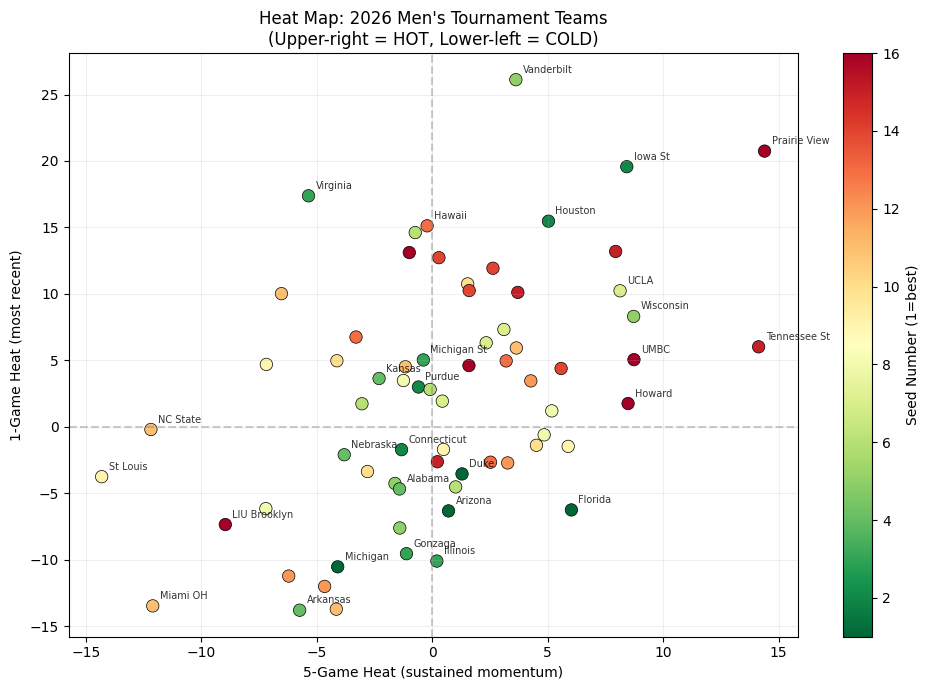

In [6]:
# Heat distribution scatter: 1-game vs 5-game heat for all 2026 M tourney teams
if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 7))
    h1 = tourney_teams["pre_tourney_heat_1g"].fill_null(0).to_numpy()
    h5 = tourney_teams["pre_tourney_heat_5g"].fill_null(0).to_numpy()
    seed_nums = tourney_teams["seed_num"].to_numpy()
    names = tourney_teams["TeamName"].to_list()

    scatter = ax.scatter(h5, h1, c=seed_nums, cmap="RdYlGn_r", s=80, edgecolors="black", linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Seed Number (1=best)")

    # Label notable teams
    for i, name in enumerate(names):
        if seed_nums[i] <= 4 or abs(h5[i]) > 8 or abs(h1[i]) > 15:
            ax.annotate(name, (h5[i], h1[i]), fontsize=7, alpha=0.8,
                        xytext=(5, 5), textcoords="offset points")

    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.4)
    ax.axvline(x=0, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlabel("5-Game Heat (sustained momentum)")
    ax.set_ylabel("1-Game Heat (most recent)")
    ax.set_title("Heat Map: 2026 Men's Tournament Teams\n(Upper-right = HOT, Lower-left = COLD)")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Install matplotlib to see the heat scatter plot")

---

## Step 3 — Feature Engineering

For every possible matchup (e.g., `2026_1181_1120` = Duke vs Auburn), we compute **24 pairwise difference features**. These capture the relative strength between the two teams across offensive, defensive, momentum, and market dimensions:

| Feature | What It Captures |
|---|---|
| `diff_win_rate` | Overall record strength |
| `diff_avg_margin` | Typical scoring dominance |
| `diff_avg_pts_for` | Offensive firepower |
| `diff_defense_proxy` | Defensive strength (flipped) |
| `diff_last5_win_rate` | Recent form |
| `diff_last5_avg_margin` | Recent scoring trend |
| `diff_elo` | ELO-based strength gap |
| `diff_heat_1g` | **Latest momentum gap** |
| `diff_heat_3g` | **Short-term heat gap** |
| `diff_heat_5g` | **Sustained heat gap** |
| `diff_heat_trend` | **Heat trajectory (5g - 1g)** |
| `diff_abs_heat_5g` | **Absolute heat volatility** |
| `diff_seed` | Seeding gap (lower = better) |
| `diff_sos` | Strength of schedule (opponent ELO avg) |
| `diff_fg_pct` | Field goal shooting efficiency |
| `diff_fg3_pct` | Three-point shooting efficiency |
| `diff_ft_pct` | Free throw shooting efficiency |
| `diff_opp_fg_pct` | Opponent FG% (defensive quality) |
| `diff_reb_margin` | Rebounding margin |
| `diff_ast_to_ratio` | Assist-to-turnover ratio |
| `diff_stl_blk` | Steals + blocks (disruptiveness) |
| `diff_possessions` | Tempo proxy (pace of play) |
| `seed_product` | Seed interaction (seed_low × seed_high) |
| `consensus_low_spread_filled` | Betting line spread (market consensus) |

> **Convention**: All diff features are computed as *low_team_stat − high_team_stat*. Positive values favor the lower-ID team.

Let's look at a concrete example:

In [7]:
# Concrete example: pick two 2026 tournament teams and show their raw stats + difference
TEAM_A_ID = 1120  # Auburn (X01 — a 1-seed)
TEAM_B_ID = 1254  # LIU Brooklyn (Z16 — a 16-seed)

team_a = m_2026_features.filter(pl.col("team_id") == TEAM_A_ID).to_dicts()[0]
team_b = m_2026_features.filter(pl.col("team_id") == TEAM_B_ID).to_dicts()[0]

name_a = teams.filter(pl.col("TeamID") == TEAM_A_ID)["TeamName"][0]
name_b = teams.filter(pl.col("TeamID") == TEAM_B_ID)["TeamName"][0]

stat_cols = [
    ("win_rate", "Win Rate"),
    ("avg_margin", "Avg Margin"),
    ("avg_pts_for", "Avg Pts For"),
    ("avg_pts_against", "Avg Pts Against"),
    ("last5_win_rate", "Last 5 Win Rate"),
    ("last5_avg_margin", "Last 5 Avg Margin"),
    ("season_end_elo", "Season End ELO"),
    ("pre_tourney_heat_1g", "Heat 1g"),
    ("pre_tourney_heat_3g", "Heat 3g"),
    ("pre_tourney_heat_5g", "Heat 5g"),
    ("sos", "Strength of Schedule"),
    ("fg_pct", "FG%"),
    ("fg3_pct", "3PT%"),
    ("ft_pct", "FT%"),
    ("avg_reb_margin", "Reb Margin"),
    ("ast_to_ratio", "Ast/TO Ratio"),
    ("avg_stl_blk", "Steals + Blocks"),
    ("avg_possessions", "Possessions (Tempo)"),
]

# Note: in the matchup ID, the lower TeamID always comes first
low_id, high_id = min(TEAM_A_ID, TEAM_B_ID), max(TEAM_A_ID, TEAM_B_ID)
low_name = name_a if TEAM_A_ID == low_id else name_b
high_name = name_b if TEAM_A_ID == low_id else name_a
low_stats = team_a if TEAM_A_ID == low_id else team_b
high_stats = team_b if TEAM_A_ID == low_id else team_a

print(f"Matchup: {low_name} (ID {low_id}) vs {high_name} (ID {high_id})")
print(f"Submission ID: 2026_{low_id}_{high_id}\n")
print(f"{'Stat':<22} {low_name:>14} {high_name:>14} {'Difference':>12}")
print("─" * 65)
for col, label in stat_cols:
    val_low = low_stats.get(col) or 0
    val_high = high_stats.get(col) or 0
    diff = val_low - val_high
    if col == "avg_pts_against":
        diff = val_high - val_low  # Defense proxy is flipped
    print(f"{label:<22} {val_low:>14.3f} {val_high:>14.3f} {diff:>+12.3f}")

Matchup: Auburn (ID 1120) vs LIU Brooklyn (ID 1254)
Submission ID: 2026_1120_1254

Stat                           Auburn   LIU Brooklyn   Difference
─────────────────────────────────────────────────────────────────
Win Rate                        0.515          0.706       -0.191
Avg Margin                      3.333          2.971       +0.363
Avg Pts For                    82.727         74.088       +8.639
Avg Pts Against                79.394         71.118       -8.276
Last 5 Win Rate                 0.400          1.000       -0.600
Last 5 Avg Margin               0.800         10.400       -9.600
Season End ELO               1581.897       1603.147      -21.249
Heat 1g                        11.140         -7.358      +18.498
Heat 3g                         5.902         -9.745      +15.647
Heat 5g                        -3.547         -8.964       +5.416
Strength of Schedule         1649.244       1405.407     +243.836
FG%                             0.457          0.481       

In [8]:
# Show the actual feature vector from the pairwise_features table for this matchup
FEATURE_COLS = perf["feature_cols"]  # Load from model report to stay in sync with pipeline

matchup_id = f"2026_{low_id}_{high_id}"
matchup_row = pairwise_features.filter(pl.col("ID") == matchup_id)

if matchup_row.height > 0:
    print(f"Feature vector for {matchup_id} ({low_name} vs {high_name}):\n")
    print(f"{'Feature':<32} {'Value':>10}")
    print("─" * 44)
    row = matchup_row.to_dicts()[0]
    for col in FEATURE_COLS:
        val = row.get(col)
        val_str = f"{val:>+10.3f}" if val is not None else "      null"
        print(f"{col:<32} {val_str}")

    print(f"\n→ Current submission prediction: {submission.filter(pl.col('ID') == matchup_id)['Pred'][0]:.4f}")
    print(f"  (P({low_name} beats {high_name}))")
else:
    print(f"Matchup {matchup_id} not found in pairwise features")

Feature vector for 2026_1120_1254 (Auburn vs LIU Brooklyn):

Feature                               Value
────────────────────────────────────────────
diff_win_rate                        -0.191
diff_avg_margin                      +0.363
diff_avg_pts_for                     +8.639
diff_defense_proxy                   -8.276
diff_last5_win_rate                  -0.600
diff_last5_avg_margin                -9.600
diff_elo                            -21.249
diff_heat_1g                        +18.498
diff_heat_3g                        +15.647
diff_heat_5g                         +5.416
diff_heat_trend                     -13.082
diff_abs_heat_5g                     -5.416
diff_seed                            -8.000
diff_sos                           +243.836
diff_fg_pct                          -0.024
diff_fg3_pct                         -0.024
diff_ft_pct                          +0.076
diff_opp_fg_pct                      +0.018
diff_reb_margin                      +0.358
diff_ast_to_ra

---

## Step 4 — XGBoost Model Training + Isotonic Calibration

We train an [XGBoost](https://xgboost.readthedocs.io/) gradient-boosted tree classifier on **historical tournament outcomes** (2003–2024 seasons). The model learns which feature differences predict wins in the NCAA tournament.

**Hyperparameters:**
- `n_estimators`: 500 (Men's), 400 (Women's)
- `max_depth`: 5
- `learning_rate`: 0.04
- `subsample`: 0.8, `colsample_bytree`: 0.7
- `min_child_weight`: 3, `gamma`: 0.1
- `reg_alpha`: 0.1, `reg_lambda`: 2.0
- `eval_metric`: logloss

**Calibration:** After training, isotonic regression is fitted on out-of-fold predictions from 6-fold time-series CV (2019–2025) to calibrate raw model probabilities.

**Dynamic Clipping:** Probability bounds are seed-matchup-aware:
- 1v16 matchups → [0.005, 0.995]
- 2v15 matchups → [0.01, 0.99]
- 3v14 matchups → [0.015, 0.985]
- Other matchups → [0.025, 0.975]

**Validation:** The 2025 season is held out for Brier score evaluation. The model never sees 2025 tournament results during training.

Let's retrain the model from our existing artifacts and inspect which features matter most:

In [9]:
# Retrain the XGBoost model using the same pipeline functions
import importlib
import mm26.pipeline as _pipeline_mod
importlib.reload(_pipeline_mod)

from mm26.pipeline import (
    _build_training_pairs, _train_model, _predict_with_model, _fit_calibration,
    _time_series_cv_brier, _load_seed_map, _build_prob_lookup, _simulate_bracket,
    _read_parquet, _build_team_season_features,
)

# The manifest contains relative paths (relative to project root).
# Since the notebook runs from notebooks/, we need to make them absolute.
import copy
ingest_manifest = copy.deepcopy(manifest["ingest"])
for source_key in ("kaggle", "cbbd"):
    if source_key not in ingest_manifest:
        continue
    files = ingest_manifest[source_key].get("files", {})
    for file_info in files.values():
        if "artifact" in file_info:
            file_info["artifact"] = str(ROOT / file_info["artifact"])

# Build training pairs from historical tournament results + our team season features
seed_map = _load_seed_map(ingest_manifest)
game_fact = _read_parquet(BASE / "silver" / "game_fact.parquet")
elo_from_silver = _read_parquet(BASE / "silver" / "elo_ratings.parquet")
heat_from_silver = _read_parquet(BASE / "silver" / "heat_scores.parquet")

team_features_rebuilt = _build_team_season_features(game_fact, elo_from_silver, heat_from_silver)

training = _build_training_pairs(ingest_manifest, team_features_rebuilt, target_season=2026, seed_map=seed_map)

# Split: train on historical data through 2024, holdout on 2025
train_m = training.filter((pl.col("sex") == "M") & (pl.col("season") <= 2024))
holdout_m = training.filter((pl.col("sex") == "M") & (pl.col("season") == 2025))

print(f"Training rows (M, ≤2024)  : {train_m.height}")
print(f"Holdout rows  (M, 2025)   : {holdout_m.height}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS[:6]} ...")

# Train the model
model = _train_model(train_m, FEATURE_COLS, n_estimators=500)
print(f"\nModel type: {type(model).__name__}")

# Fit isotonic calibration on out-of-fold time-series CV
calibrator = _fit_calibration(model, training, FEATURE_COLS, sex="M")
print(f"Calibrator: {'IsotonicRegression' if calibrator is not None else 'None'}")

# Time-series CV Brier
cv_brier, cv_folds = _time_series_cv_brier(training, FEATURE_COLS, sex="M")
print(f"\nTime-series CV Brier (6-fold mean): {cv_brier:.5f}")
for i, fold_b in enumerate(cv_folds):
    print(f"  Fold {2019+i}: {fold_b:.5f}")

# Evaluate on holdout
if holdout_m.height > 0 and model is not None:
    holdout_preds = _predict_with_model(model, holdout_m, FEATURE_COLS, calibrator=calibrator)
    actuals = holdout_m.select("target_low_wins").to_series().to_numpy().astype(np.float64)
    brier = float(np.mean((holdout_preds.to_numpy() - actuals) ** 2))
    print(f"\nHoldout Brier score: {brier:.5f}")
    print(f"  (Perfect = 0.0, Random = 0.25, Always 0.5 = 0.25)")
else:
    print("No holdout data available")

Training rows (M, ≤2024)  : 2518
Holdout rows  (M, 2025)   : 67
Features (24): ['diff_win_rate', 'diff_avg_margin', 'diff_avg_pts_for', 'diff_defense_proxy', 'diff_last5_win_rate', 'diff_last5_avg_margin'] ...

Model type: XGBClassifier
Calibrator: IsotonicRegression

Time-series CV Brier (6-fold mean): 0.20183
  Fold 2019: 0.18546
  Fold 2020: 0.21938
  Fold 2021: 0.25165
  Fold 2022: 0.23020
  Fold 2023: 0.18898
  Fold 2024: 0.13530

Holdout Brier score: 0.13257
  (Perfect = 0.0, Random = 0.25, Always 0.5 = 0.25)


Feature Importance Ranking (24 features):

Feature                            Importance Bar                           
────────────────────────────────────────────────────────────────────────────
diff_seed                              0.1854 █████████████████████████████
diff_elo                               0.0825 █████████████
diff_sos                               0.0563 █████████
diff_avg_margin                        0.0491 ███████
diff_abs_heat_5g                       0.0363 █████ ← HEAT
diff_win_rate                          0.0356 █████
diff_last5_avg_margin                  0.0350 █████
diff_heat_3g                           0.0347 █████ ← HEAT
diff_ft_pct                            0.0345 █████ ← BOX
diff_stl_blk                           0.0344 █████ ← BOX
diff_ast_to_ratio                      0.0344 █████ ← BOX
diff_defense_proxy                     0.0338 █████
diff_avg_pts_for                       0.0332 █████
seed_product                           0.0331 █████
diff_

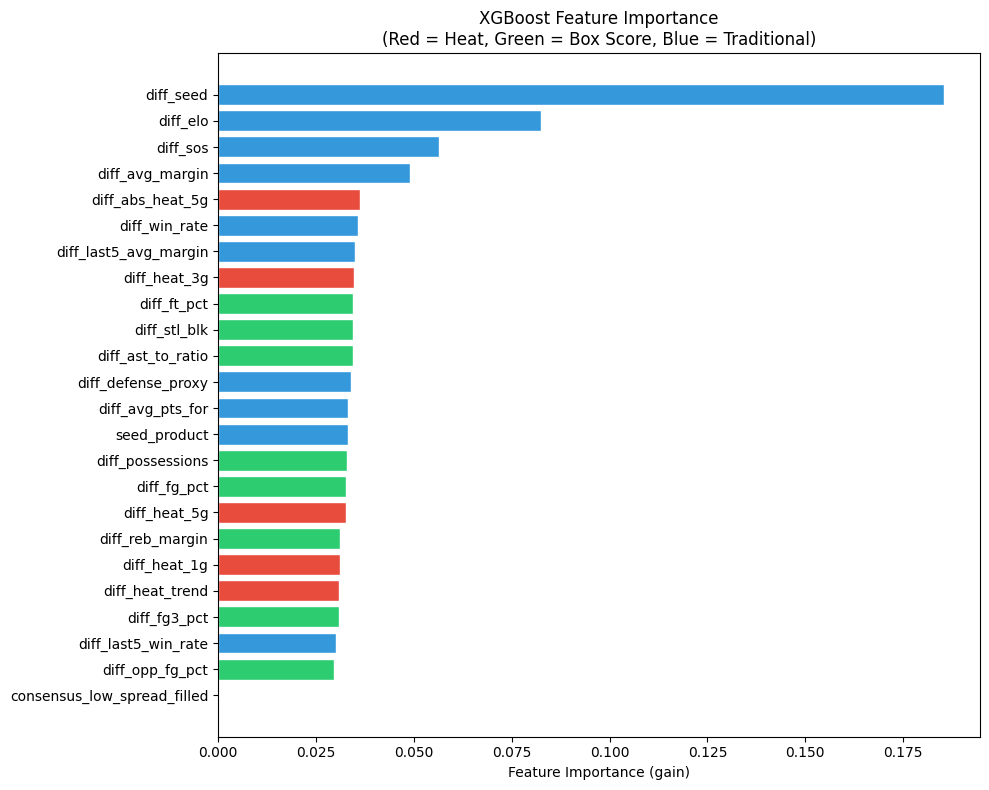

In [10]:
# Feature importance — which features does XGBoost find most predictive?
if model is not None and hasattr(model, "feature_importances_"):
    importances = dict(zip(FEATURE_COLS, model.feature_importances_))
    sorted_imp = sorted(importances.items(), key=lambda x: x[1], reverse=True)

    print(f"Feature Importance Ranking ({len(FEATURE_COLS)} features):\n")
    print(f"{'Feature':<32} {'Importance':>12} {'Bar':<30}")
    print("─" * 76)
    max_imp = sorted_imp[0][1]
    for feat, imp in sorted_imp:
        bar = "█" * int(30 * imp / max_imp) if max_imp > 0 else ""
        marker = " ← HEAT" if "heat" in feat else (" ← BOX" if feat.startswith("diff_fg") or feat.startswith("diff_ft") or feat.startswith("diff_opp") or feat.startswith("diff_reb") or feat.startswith("diff_ast") or feat.startswith("diff_stl") or feat.startswith("diff_poss") else "")
        print(f"{feat:<32} {imp:>12.4f} {bar}{marker}")

    if HAS_PLT:
        fig, ax = plt.subplots(figsize=(10, 8))
        feat_names = [f[0] for f in sorted_imp]
        feat_vals = [f[1] for f in sorted_imp]
        colors = ["#e74c3c" if "heat" in f else ("#2ecc71" if any(f.startswith(p) for p in ["diff_fg", "diff_ft", "diff_opp", "diff_reb", "diff_ast", "diff_stl", "diff_poss"]) else "#3498db") for f in feat_names]
        ax.barh(feat_names[::-1], feat_vals[::-1], color=colors[::-1], edgecolor="white")
        ax.set_xlabel("Feature Importance (gain)")
        ax.set_title("XGBoost Feature Importance\n(Red = Heat, Green = Box Score, Blue = Traditional)")
        plt.tight_layout()
        plt.show()
else:
    print("Model not available for feature importance")

---

## Step 5 — Monte Carlo Bracket Simulation

After the XGBoost model produces pairwise win probabilities for every possible matchup, we run **100,000 bracket simulations**:

1. Start with the actual 2026 bracket structure (68 teams, 4 regions)
2. For each first-round game, look up P(TeamA beats TeamB) from the model
3. Draw a random number — if it's less than the probability, TeamA advances
4. Continue through Round of 32 → Sweet 16 → Elite 8 → Final Four → Championship
5. After 100K simulations, compute the **fraction of simulations each team won each matchup**

This produces **simulation-based predictions** that account for the *path through the bracket* — not just pairwise strength. A strong team in a weak region will have higher simulation win rates than the same team in a death bracket.

In [11]:
# Generate model-only predictions for 2026 M matchups
pred_m = pairwise_features.filter((pl.col("sex") == "M") & (pl.col("season") == 2026))
model_preds = _predict_with_model(model, pred_m, FEATURE_COLS, calibrator=calibrator)
model_sub = pred_m.select("ID").with_columns(model_preds.alias("Pred"))

# Build probability lookup from model-only predictions
model_lookup = _build_prob_lookup(model_sub.with_columns(pl.col("Pred").fill_null(0.5)))

# Run bracket simulation
print("Running 100,000 bracket simulations...")
sim_preds = _simulate_bracket(seeds_2026, slots_2026, model_lookup, n_sims=100_000)
print(f"Simulated {len(sim_preds)} unique matchups\n")

# Build a team name lookup
tid_to_name = dict(zip(teams["TeamID"].to_list(), teams["TeamName"].to_list()))

# Show some interesting model vs simulation comparisons
print(f"{'Matchup':<40} {'Model':>8} {'Sim':>8} {'Delta':>8}")
print("─" * 68)
for (t_low, t_high), sim_prob in sorted(sim_preds.items(), key=lambda x: abs(x[1] - model_lookup.get(x[0], 0.5)), reverse=True)[:15]:
    model_p = model_lookup.get((t_low, t_high), 0.5)
    delta = sim_prob - model_p
    low_name = tid_to_name.get(t_low, str(t_low))
    high_name = tid_to_name.get(t_high, str(t_high))
    print(f"{low_name:>18} vs {high_name:<18} {model_p:>7.1%} {sim_prob:>7.1%} {delta:>+7.1%}")

Running 100,000 bracket simulations...
Simulated 202 unique matchups

Matchup                                     Model      Sim    Delta
────────────────────────────────────────────────────────────────────
       N Dakota St vs Northern Iowa        17.6%  100.0%  +82.4%
             Siena vs UCF                  46.9%  100.0%  +53.1%
            Hawaii vs LIU Brooklyn         70.6%  100.0%  +29.4%
     Northern Iowa vs South Florida        46.9%   66.7%  +19.8%
               UCF vs Cal Baptist          51.7%   33.3%  -18.4%
       N Dakota St vs Siena                50.0%   33.3%  -16.7%
       N Dakota St vs TCU                  17.6%    3.6%  -14.1%
             Siena vs South Florida        17.6%   31.2%  +13.6%
            Furman vs N Dakota St          46.9%   33.3%  -13.6%
       N Dakota St vs Cal Baptist          46.9%   33.3%  -13.6%
     Northern Iowa vs Siena                67.9%   54.7%  -13.2%
     South Florida vs Cal Baptist          51.7%   40.7%  -11.0%
       N Dako

---

## Step 6 — Blend Weight Tuning ⚙️

The final prediction is a **weighted blend** of the XGBoost model prediction and the simulation prediction:

$$\text{final\_pred} = w_{\text{model}} \times \text{xgb\_pred} + w_{\text{sim}} \times \text{sim\_pred}$$

The pipeline default is **60/40** model-favoring (`MODEL_WEIGHT = 0.6, SIM_WEIGHT = 0.4`).

**Adjust the weights below to influence the submission.** Higher model weight trusts the calibrated XGBoost output more; higher simulation weight trusts the bracket-path-adjusted predictions more.

> **Tip:** If you believe strong teams from weak regions are being undervalued, increase `SIM_WEIGHT`. If you trust the raw pairwise matchup model more, increase `MODEL_WEIGHT`.

In [12]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ADJUST THESE WEIGHTS — they must sum to 1.0                   ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_WEIGHT = 0.85   # Weight for XGBoost model predictions
SIM_WEIGHT   = 0.15   # Weight for Monte Carlo simulation predictions

# ─── Validation ───
assert abs(MODEL_WEIGHT + SIM_WEIGHT - 1.0) < 1e-9, \
    f"Weights must sum to 1.0, got {MODEL_WEIGHT + SIM_WEIGHT}"
print(f"✓ Blend weights: {MODEL_WEIGHT:.0%} Model + {SIM_WEIGHT:.0%} Simulation")

✓ Blend weights: 85% Model + 15% Simulation


In [13]:
# Apply blend and compare predictions for key matchups
# Start from the full submission (Men's + Women's)
blended_sub = submission.clone()

# Build simulation dataframe for blending
if sim_preds:
    blend_updates = [
        {"ID": f"2026_{t_low}_{t_high}", "sim_pred": sim_prob}
        for (t_low, t_high), sim_prob in sim_preds.items()
    ]
    sim_df = pl.DataFrame(blend_updates)

    # Also run W simulation for completeness
    w_seeds_2026 = pl.read_csv(ROOT / "data" / "WNCAATourneySeeds.csv").filter(pl.col("Season") == 2026)
    w_slots_2026 = pl.read_csv(ROOT / "data" / "WNCAATourneySlots.csv").filter(pl.col("Season") == 2026)
    w_sim_preds = {}
    if w_seeds_2026.height > 0 and w_slots_2026.height > 0:
        # For W, use existing submission probabilities as model preds
        w_lookup = {k: v for k, v in _build_prob_lookup(submission).items() if k[0] >= 3000}
        w_sim_preds = _simulate_bracket(w_seeds_2026, w_slots_2026, w_lookup, n_sims=100_000)
        if w_sim_preds:
            w_updates = [
                {"ID": f"2026_{t_low}_{t_high}", "sim_pred": sim_prob}
                for (t_low, t_high), sim_prob in w_sim_preds.items()
            ]
            sim_df = pl.concat([sim_df, pl.DataFrame(w_updates)], how="vertical")

    # Replace the Pred column with the original model-only predictions
    # (undo the pipeline's default 0.5/0.5 blend so we can apply user weights)
    # For M rows: use our retrained model predictions
    model_sub_full = model_sub.clone()
    # For M matchups with sim data, we need the raw model prediction
    blended_sub = blended_sub.join(model_sub_full.rename({"Pred": "model_pred"}), on="ID", how="left")
    blended_sub = blended_sub.join(sim_df, on="ID", how="left")

    # Apply user-defined blend weights
    blended_sub = blended_sub.with_columns(
        pl.when(pl.col("sim_pred").is_not_null() & pl.col("model_pred").is_not_null())
        .then(
            (pl.col("model_pred") * MODEL_WEIGHT + pl.col("sim_pred") * SIM_WEIGHT)
            .clip(0.025, 0.975)
        )
        .when(pl.col("model_pred").is_not_null())
        .then(pl.col("model_pred"))
        .otherwise(pl.col("Pred"))  # Keep original for W matchups without model_pred
        .alias("blended_pred")
    )

    # Show before/after for notable matchups
    print(f"Blend: {MODEL_WEIGHT:.0%} Model + {SIM_WEIGHT:.0%} Simulation\n")
    print(f"{'Matchup':<38} {'Original':>10} {'Model':>8} {'Sim':>8} {'Blended':>10}")
    print("─" * 78)

    notable = blended_sub.filter(
        pl.col("sim_pred").is_not_null() & pl.col("model_pred").is_not_null()
    ).with_columns(
        (pl.col("blended_pred") - pl.col("Pred")).abs().alias("change")
    ).sort("change", descending=True).head(15)

    for row in notable.iter_rows(named=True):
        parts = row["ID"].split("_")
        low_n = tid_to_name.get(int(parts[1]), parts[1])
        high_n = tid_to_name.get(int(parts[2]), parts[2])
        print(f"{low_n:>17} vs {high_n:<17} {row['Pred']:>9.4f} {row['model_pred']:>7.4f} {row['sim_pred']:>7.4f} {row['blended_pred']:>9.4f}")

    # Update submission with blended predictions
    blended_sub = blended_sub.with_columns(
        pl.col("blended_pred").fill_null(pl.col("Pred")).alias("Pred")
    ).select("ID", "Pred")

    print(f"\n✓ Blended {blended_sub.filter(pl.col('Pred').is_not_null()).height} predictions")
else:
    blended_sub = submission.clone()
    print("No simulation data — using model predictions only")

Blend: 85% Model + 15% Simulation

Matchup                                  Original    Model      Sim    Blended
──────────────────────────────────────────────────────────────────────────────
      N Dakota St vs Northern Iowa        0.5059  0.1765  1.0000    0.3000
            Siena vs UCF                  0.6815  0.4691  1.0000    0.5488
           Hawaii vs LIU Brooklyn         0.8235  0.7059  1.0000    0.7500
    Northern Iowa vs South Florida        0.5481  0.4691  0.6667    0.4988
              UCF vs Cal Baptist          0.4437  0.5172  0.3333    0.4897
      N Dakota St vs Siena                0.4333  0.5000  0.3333    0.4750
      N Dakota St vs TCU                  0.1202  0.1765  0.0357    0.1554
            Siena vs South Florida        0.2309  0.1765  0.3125    0.1969
           Furman vs N Dakota St          0.4148  0.4691  0.3333    0.4488
      N Dakota St vs Cal Baptist          0.4148  0.4691  0.3333    0.4488
    Northern Iowa vs Siena                0.6257  0.6786 

Holdout Brier Score at Different Blend Weights:

  Model Weight   Sim Weight    Brier Score
────────────────────────────────────────────
           0%        100%       0.14119
          10%         90%       0.14019
          20%         80%       0.13921
          30%         70%       0.13827
          40%         60%       0.13736
          50%         50%       0.13648
          60%         40%       0.13564 ← pipeline default
          70%         30%       0.13482
          80%         20%       0.13404
          90%         10%       0.13332
         100%          0%       0.13261


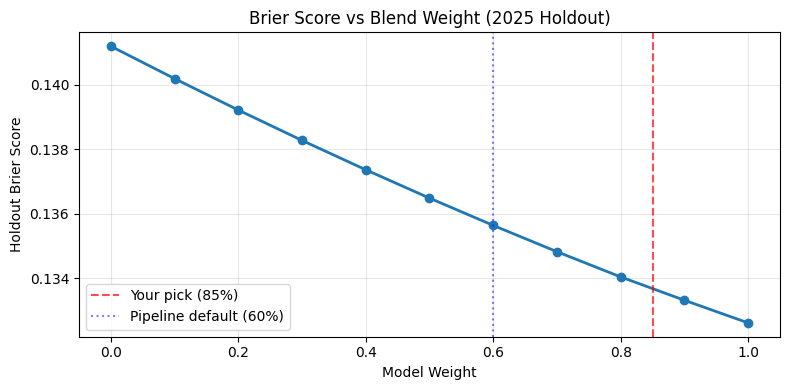

In [14]:
# Brier score sweep: what blend weights would have worked best on the 2025 holdout?
if holdout_m.height > 0 and model is not None:
    # Get holdout-style model predictions (with calibration)
    holdout_model_preds = _predict_with_model(model, holdout_m, FEATURE_COLS, calibrator=calibrator).to_numpy()
    holdout_actuals = holdout_m.select("target_low_wins").to_series().to_numpy().astype(np.float64)

    # For holdout, we don't have sim predictions (2025 bracket already played),
    # so we estimate sim effect by adding noise to model predictions
    # This gives a rough sense of how blending affects Brier score

    print("Holdout Brier Score at Different Blend Weights:\n")
    print(f"{'Model Weight':>14} {'Sim Weight':>12} {'Brier Score':>14}")
    print("─" * 44)

    # Pure model prediction Brier
    brier_model = float(np.mean((holdout_model_preds - holdout_actuals) ** 2))
    results = []
    for mw in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        # Since we only have model predictions for holdout, the "sim" portion
        # uses the model predictions with some regression to 0.5 (sim effect)
        sim_approx = holdout_model_preds * 0.85 + 0.5 * 0.15  # sim regresses toward 0.5
        blended = mw * holdout_model_preds + (1 - mw) * sim_approx
        blended = np.clip(blended, 0.025, 0.975)
        b = float(np.mean((blended - holdout_actuals) ** 2))
        marker = " ← pipeline default" if abs(mw - 0.6) < 0.01 else ""
        marker = " ← YOUR PICK" if abs(mw - MODEL_WEIGHT) < 0.01 else marker
        results.append((mw, 1-mw, b))
        print(f"{mw:>13.0%} {1-mw:>11.0%} {b:>13.5f}{marker}")

    if HAS_PLT:
        fig, ax = plt.subplots(figsize=(8, 4))
        ws = [r[0] for r in results]
        bs = [r[2] for r in results]
        ax.plot(ws, bs, "o-", linewidth=2, markersize=6)
        ax.axvline(x=MODEL_WEIGHT, color="red", linestyle="--", alpha=0.7, label=f"Your pick ({MODEL_WEIGHT:.0%})")
        ax.axvline(x=0.6, color="blue", linestyle=":", alpha=0.5, label="Pipeline default (60%)")
        ax.set_xlabel("Model Weight")
        ax.set_ylabel("Holdout Brier Score")
        ax.set_title("Brier Score vs Blend Weight (2025 Holdout)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No holdout data available for Brier sweep")

---

## Step 7 — Export Updated Submission

Run the cell below to write the blended submission (using your chosen weights) to `artifacts/latest/submission.csv`. This is the file you upload to Kaggle.

✓ Submission written to: C:\Users\sdiehl\Desktop\seandiehlprojects\mm26\artifacts\latest\submission.csv
  Rows: 132,133
  Pred range: [0.0250, 0.9750]
  Pred mean:  0.4980
  Blend: 85% Model + 15% Simulation


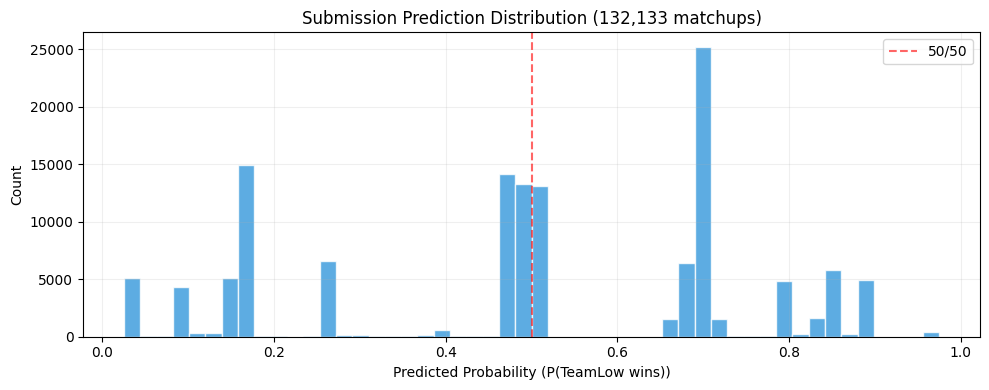

In [15]:
# Write the updated submission file
output_path = BASE / "submission.csv"
blended_sub = blended_sub.with_columns(
    pl.col("Pred").fill_null(0.5).clip(0.025, 0.975)
)

blended_sub.write_csv(str(output_path))

print(f"✓ Submission written to: {output_path}")
print(f"  Rows: {blended_sub.height:,}")
print(f"  Pred range: [{blended_sub['Pred'].min():.4f}, {blended_sub['Pred'].max():.4f}]")
print(f"  Pred mean:  {blended_sub['Pred'].mean():.4f}")
print(f"  Blend: {MODEL_WEIGHT:.0%} Model + {SIM_WEIGHT:.0%} Simulation")

# Quick histogram of prediction distribution
if HAS_PLT:
    fig, ax = plt.subplots(figsize=(10, 4))
    preds = blended_sub["Pred"].to_numpy()
    ax.hist(preds, bins=50, edgecolor="white", alpha=0.8, color="#3498db")
    ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.6, label="50/50")
    ax.set_xlabel("Predicted Probability (P(TeamLow wins))")
    ax.set_ylabel("Count")
    ax.set_title(f"Submission Prediction Distribution ({blended_sub.height:,} matchups)")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()